# Define jaggedness

In this notebook we will present progressively better definitions of "jaggedness" (actual name pending).

This is a measure that allows us to predict the way in which a defect may spread through a network, based on the LLNA's local update rule and the the networks' degree distribution.

## General principles

In the context of LLNAs, introducing a single defect has two effects:
1. The node that changes state will obey a different update rule
2. The nodes in the changed node's neighbourhood will experience a change in their neighbourhood's state density

These changes can have a big effect or a small effect on the dynamics of the system.

## The naive definition

In [2]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

In the first definition we only look at the effect of slightly modifying the local density. In particular we look at how many opportunities the LLNA has to change its output when a defect is introduced. We quantify this by counting the number of 'edges' in the diagram of the local update rule. Some examples are listed below:

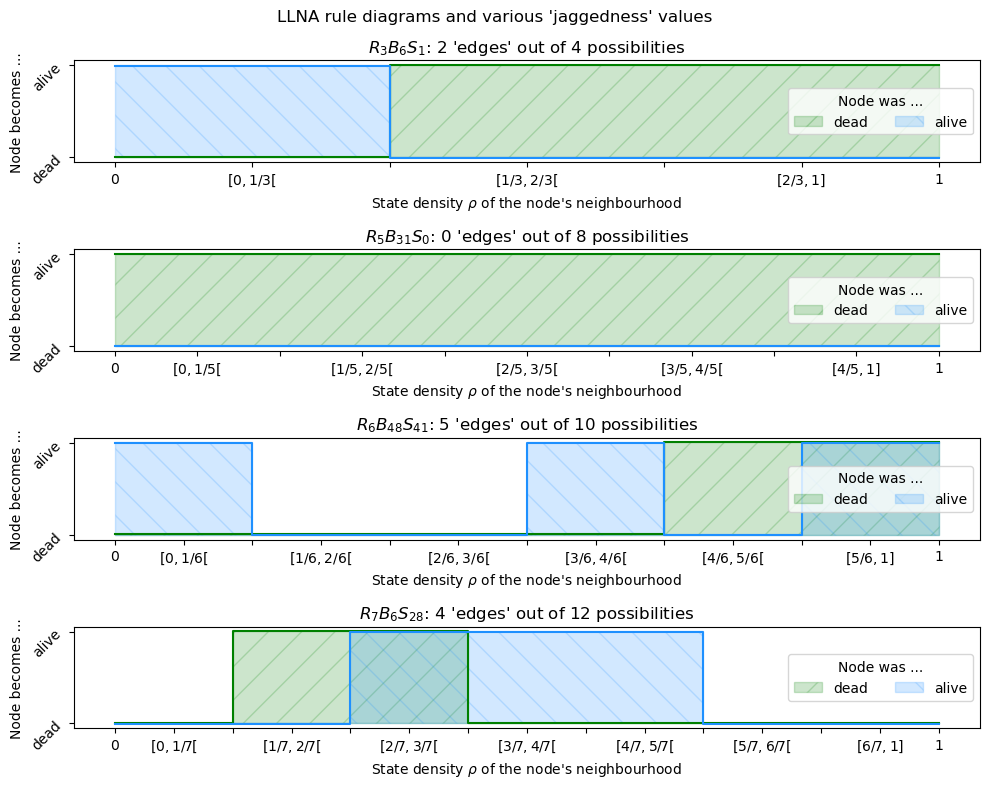

In [16]:
SAVEFIG=False

fig, axs = plt.subplots(4,1,figsize=(10, 8))

resolution = 3
born_if = [1, 2]
survive_if = [0]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[0])
axs[0].set_title(f"{model.__str__(latex=True)}: 2 'edges' out of 4 possibilities")

resolution = 5
born_if = [0, 1, 2, 3, 4]
survive_if = []
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[1])
axs[1].set_title(f"{model.__str__(latex=True)}: 0 'edges' out of 8 possibilities")

resolution = 6
born_if = [4, 5]
survive_if = [0, 3, 5]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[2])
axs[2].set_title(f"{model.__str__(latex=True)}: 5 'edges' out of 10 possibilities")

resolution = 7
born_if = [1, 2]
survive_if = [2, 3, 4]
model = LLNA(resolution, x=born_if, y=survive_if)
model.diagram(ax=axs[3])
axs[3].set_title(f"{model.__str__(latex=True)}: 4 'edges' out of 12 possibilities")

fig.suptitle("LLNA rule diagrams and various 'jaggedness' values")
fig.tight_layout()

Note:
1. We do not count the outer edges (those at $\rho = 0$ and $\rho = 1$) because they cannot be crossed.
2. The $B$ set has the same number of edges as the $B^\text{C}$ set, so the representation does not matter.
3. There are always $2(R-1)$ possible edges.
4. There are more possibilities with an average number of edges than with a low or high number of edges.

In [ ]:
def naive_jaggedness(resolution, B_set, S_set):
    # the number of edges normalised over the maximally possible number of edges
    edges = 0
    if B_set.size!=0
    return j